In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
maru_data = pd.read_csv("maru_data.csv")

In [ ]:
maru_data

,segments,contact_cost,response_rate,workers_needed,worker_labor_cost_per_hr,instructors_needed,instructor_labor_cost_per_hr,price_per_hr,annual_hours,retention_rate,interest_rate
0,little leaguers,1000,0.100,2,1500,1,3000,6500,10.0,0.75,0.1
1,summer sluggers,1500,0.150,1,1500,0,0,3000,4.0,0.50,0.1
2,elite ballplayers (print ad),300,0.005,1,1500,1,4500,7500,20.0,0.60,0.1
3,elite ballplayers (party),12500,0.250,1,1500,1,4500,7500,20.0,0.60,0.1
4,entertainment seekers,50,0.025,2,1500,0,0,4000,1.5,0.35,0.1


# **Part I: Case Questions**

## **Calculate annual margin**

In [ ]:
maru_data['total_cost_per_hr'] = (maru_data['instructor_labor_cost_per_hr'] * maru_data['instructors_needed'] +
                                  maru_data['worker_labor_cost_per_hr'] * maru_data['workers_needed'])
maru_data['margin_hr'] = maru_data['price_per_hr'] - maru_data['total_cost_per_hr']
maru_data['annual_margin'] = maru_data['margin_hr'] * maru_data['annual_hours']

In [ ]:
maru_data['annual_margin']

,annual_margin
0,5000.0
1,6000.0
2,30000.0
3,30000.0
4,1500.0


## **Case Q1: Calculate aquisition cost**

In [ ]:
maru_data['acquisition_cost'] = maru_data['contact_cost'] / maru_data['response_rate']
maru_data['acquisition_cost']

,acquisition_cost
0,10000.0
1,10000.0
2,60000.0
3,50000.0
4,2000.0


## **Case Q3: Calculating Customer Lifetime Value (CLV) with Infinite Time Horizon**
The formula used is:

$$
\text{Net CLV} = \left(M \times \frac{(1 + i)}{(1 + i - R)}\right) - \text{AC}
$$

where:
- **`M`**: The annual margin for each customer.
- **`i`**: The interest rate (or discount rate).
- **`R`**: The retention rate, or the probability of a customer staying each period.
- **`AC`**: The acquisition cost per customer.


In [ ]:
maru_data['clv'] = (maru_data['annual_margin'] *
                    ((1 + maru_data['interest_rate']) / (1 + maru_data['interest_rate'] - maru_data['retention_rate'])) -
                    maru_data['acquisition_cost'])

In [ ]:
maru_data['clv']

,clv
0,5714.285714
1,1000.000000
2,6000.000000
3,16000.000000
4,200.000000


## **Case Q4: The most attractive customer segment (1 point)**

In [ ]:
maru_data[['segments','annual_margin', 'acquisition_cost', 'clv']]


,segments,annual_margin,acquisition_cost,clv
0,little leaguers,5000.0,10000.0,5714.285714
1,summer sluggers,6000.0,10000.0,1000.000000
2,elite ballplayers (print ad),30000.0,60000.0,6000.000000
3,elite ballplayers (party),30000.0,50000.0,16000.000000
4,entertainment seekers,1500.0,2000.0,200.000000


## **Case Q5: Chiyoda ward (1 point)**

In [ ]:
clv_littleleaguers_now = maru_data[maru_data['segments'] == 'little leaguers']['clv']
clv_littleleaguers_now

,clv
0,5714.285714


In [ ]:
clv_littleleaguers_chiyoda = 5000 * (1 + 0.1) / (1 + 0.1 - 0.65) - (600 / 0.08)
clv_littleleaguers_chiyoda

4722.222222222221

## **Case Q6: Elite ballplayers discount (1 point)**

In [ ]:
# Retrieve the current CLV for elite ballplayers (party)
clv_eliteballplayers_now = maru_data[maru_data['segments'] == 'elite ballplayers (party)']['clv']
clv_eliteballplayers_now

,clv
3,16000.0


In [ ]:
# Calculate the CLV with the discount
# Revenue per hour is reduced from 7500 to 7000, and annual hours are 20.
# Annual Margin = (New Price per Hour - Cost per Hour) * Annual Hours
clv_eliteballplayers_discount = ((7000 - 6000) * 20) * (1 + 0.1) / (1 + 0.1 - 0.75) - 50000 + (500 * 20)
clv_eliteballplayers_discount

22857.14285714284

# **Part II: Sensitivity Analysis (3 points)**

In [ ]:
# Baseline values for the "Elite-Ballplayers (Party)" segment
baseline_ac = 50000  # Acquisition cost
baseline_am = 30000  # Annual margin
baseline_rr = 0.60   # Retention rate
interest_rate = 0.10  # Discount rate

In [ ]:
# Define alternative values for sensitivity analysis
ac_values = np.array([40000, 45000, 50000, 55000, 60000])  # Acquisition cost scenarios
am_values = np.array([20000, 25000, 30000, 35000, 40000])  # Annual margin scenarios
rr_values = np.array([0.30, 0.45, 0.60, 0.75, 0.90])  # Retention rate scenarios

In [ ]:
# Function to calculate CLV
def calculate_clv(ac, am, rr, ir=interest_rate):
    return am * ((1 + ir) / (1 + ir - rr)) - ac

# Sensitivity Analysis on Acquisition Cost (holding rr and am constant)
clv_ac = [calculate_clv(ac, baseline_am, baseline_rr) for ac in ac_values]

# Sensitivity Analysis on Annual Margin (holding ac and rr constant)
clv_am = [calculate_clv(baseline_ac, am, baseline_rr) for am in am_values]
# Sensitivity Analysis on Retention Rate (holding ac and am constant)
clv_rr = [calculate_clv(baseline_ac, baseline_am, rr) for rr in rr_values]


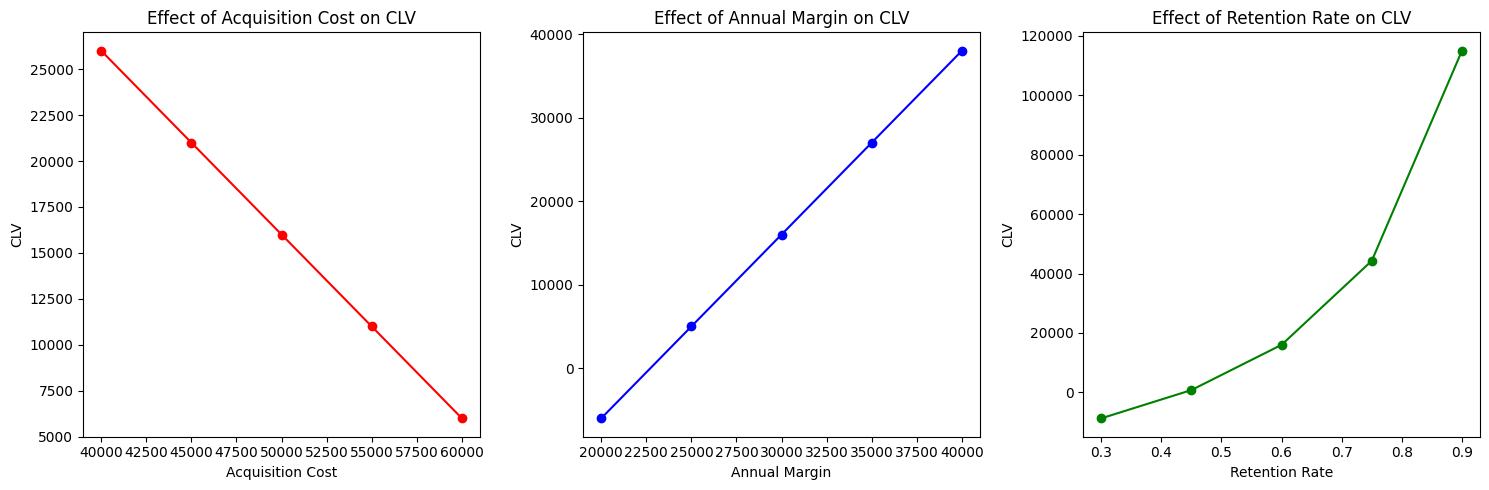

In [ ]:
# Create a single figure for all three plots in one horizontal line
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot CLV vs. Acquisition Cost
axes[0].plot(ac_values, clv_ac, marker='o', linestyle='-', color='red')
axes[0].set_xlabel('Acquisition Cost')
axes[0].set_ylabel('CLV')
axes[0].set_title('Effect of Acquisition Cost on CLV')


# Plot CLV vs. Annual Margin
axes[1].plot(am_values, clv_am, marker='o', linestyle='-', color='blue')
axes[1].set_xlabel('Annual Margin')
axes[1].set_ylabel('CLV')
axes[1].set_title('Effect of Annual Margin on CLV')

# Plot CLV vs. Retention Rate
axes[2].plot(rr_values, clv_rr, marker='o', linestyle='-', color='green')
axes[2].set_xlabel('Retention Rate')
axes[2].set_ylabel('CLV')
axes[2].set_title('Effect of Retention Rate on CLV')


# Adjust layout and display the plots
plt.tight_layout()
plt.show()


# **Part III Monte Carlo (6 points)**

In [ ]:
elite_ballplayers = maru_data.iloc[3]  # 4th row in zero-indexed Python
ac = elite_ballplayers["acquisition_cost"]
m = elite_ballplayers["annual_margin"]
r = elite_ballplayers["retention_rate"]
elite_ballplayers_clvaggregate = elite_ballplayers["clv"]

In [ ]:
ac

50000.0

In [ ]:
m

30000.0

In [ ]:
r

0.6

In [ ]:
elite_ballplayers_clvaggregate

15999.999999999985

In [ ]:
from scipy.stats import shapiro, norm

In [ ]:
# Load the customer margin data as a DataFrame and convert it to a Series
customers= pd.read_csv("customers.csv", header=None)
customers

,0
0,32101.38188
1,31824.26642
2,36026.44128
3,29321.40836
4,25518.51806
...,...
495,31478.14581
496,30472.63742
497,30422.50571
498,24853.16627


(array([ 3.,  1.,  4.,  7., 13., 17., 26., 37., 49., 39., 65., 65., 53.,
        35., 37., 24., 15.,  3.,  2.,  5.]),
 array([14812.93368 , 16231.514802, 17650.095924, 19068.677046,
        20487.258168, 21905.83929 , 23324.420412, 24743.001534,
        26161.582656, 27580.163778, 28998.7449  , 30417.326022,
        31835.907144, 33254.488266, 34673.069388, 36091.65051 ,
        37510.231632, 38928.812754, 40347.393876, 41765.974998,
        43184.55612 ]),
 <BarContainer object of 20 artists>)

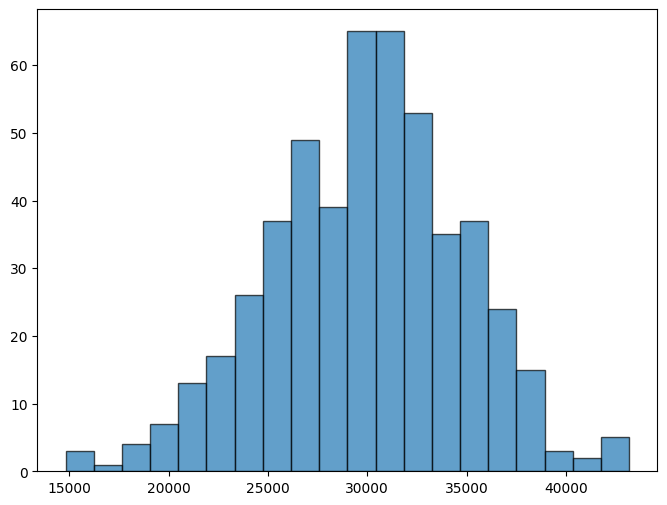

In [ ]:
# Plot a histogram
plt.figure(figsize=(8, 6))
plt.hist(customers[0], bins=20, edgecolor='black', alpha=0.7)

In [ ]:
customers.mean()

,0
0,29949.879055


In [ ]:
customers.std()

,0
0,4798.066392


In [ ]:
num_samples = 10000
m_vec = np.random.normal(customers.mean(), customers.std(), num_samples)

In [ ]:
from scipy.stats import beta

In [ ]:
a_1 = 5
b_1 = a_1 * (1 - r) / r

In [ ]:
b_1

3.3333333333333335

In [ ]:
# Function to calculate CLV
def calculate_clv(m_vec, r_vec, d, ac):
    return (m_vec * ((1 + d) / (1 + d - r_vec))) - ac

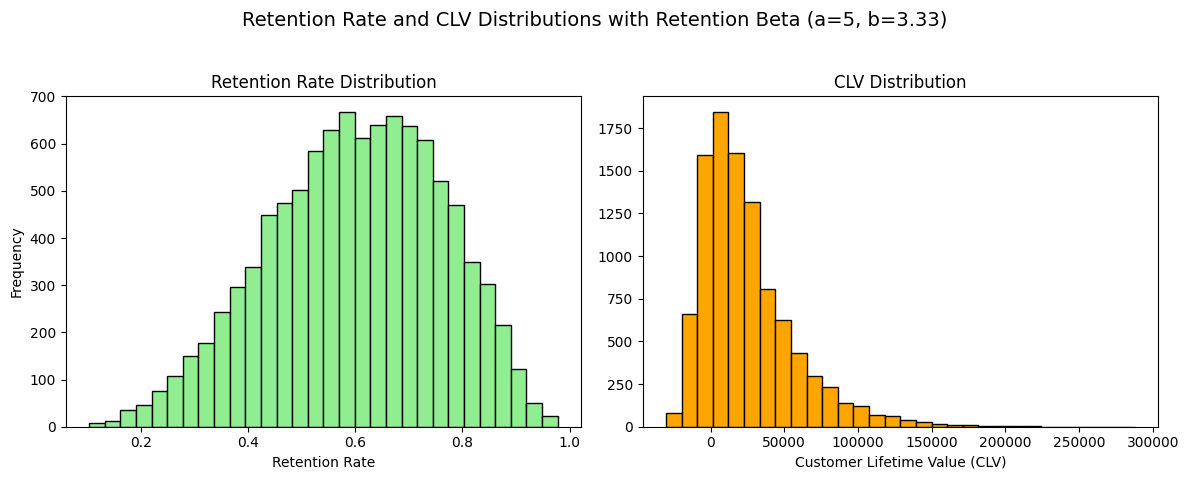

In [ ]:
d=0.1
r_vec_1 = beta.rvs(a_1, b_1, size=num_samples)

# Create a figure for the side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First plot: Retention Rate
ax1.hist(r_vec_1, bins=30, color='lightgreen', edgecolor='black')
ax1.set_title("Retention Rate Distribution")
ax1.set_xlabel("Retention Rate")
ax1.set_ylabel("Frequency")


# Second plot: CLV Distribution
clv_vec_1 = calculate_clv(m_vec, r_vec_1, d, ac)
ax2.hist(clv_vec_1, bins=30, color='orange', edgecolor='black')
ax2.set_title("CLV Distribution")
ax2.set_xlabel("Customer Lifetime Value (CLV)")

# Overall title with dynamic a_1 and b_1 values
fig.suptitle(f"Retention Rate and CLV Distributions with Retention Beta (a={a_1}, b={b_1:.2f})", fontsize=14)

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
a_2 = 0.5
b_2 = a_2 * (1 - r) / r

In [ ]:
b_2

0.33333333333333337

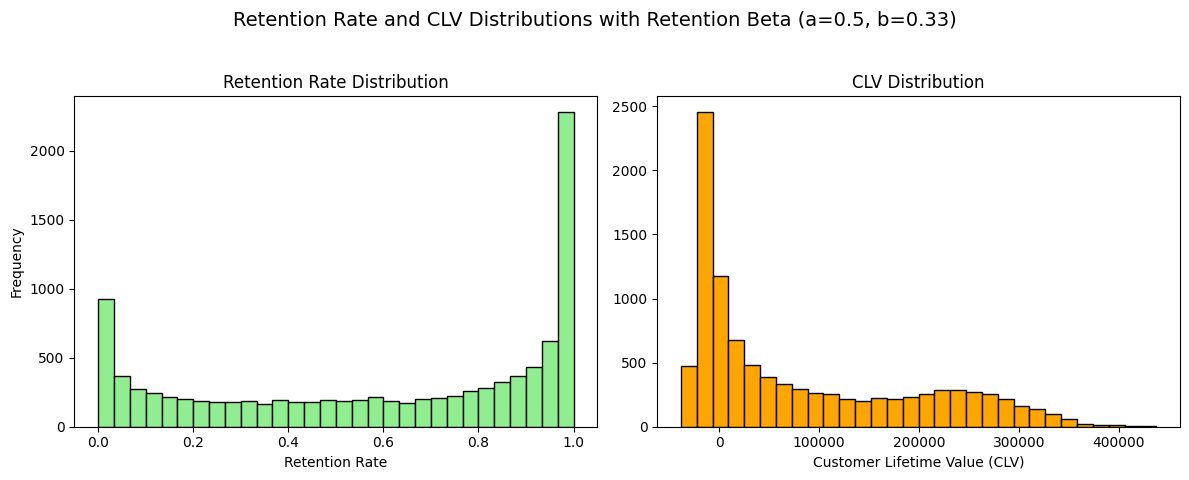

In [ ]:
r_vec_2 = beta.rvs(a_2, b_2, size=num_samples)
# Create a figure for the side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First plot: Retention Rate
ax1.hist(r_vec_2, bins=30, color='lightgreen', edgecolor='black')
ax1.set_title("Retention Rate Distribution")
ax1.set_xlabel("Retention Rate")
ax1.set_ylabel("Frequency")

# Second plot: CLV Distribution
clv_vec_2 = calculate_clv(m_vec, r_vec_2, d, ac)
ax2.hist(clv_vec_2, bins=30, color='orange', edgecolor='black')
ax2.set_title("CLV Distribution")
ax2.set_xlabel("Customer Lifetime Value (CLV)")

# Overall title with dynamic a_1 and b_1 values
fig.suptitle(f"Retention Rate and CLV Distributions with Retention Beta (a={a_2}, b={b_2:.2f})", fontsize=14)

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
a_3 = 100
b_3 = a_3 * (1 - r) / r

In [ ]:
b_3

66.66666666666667

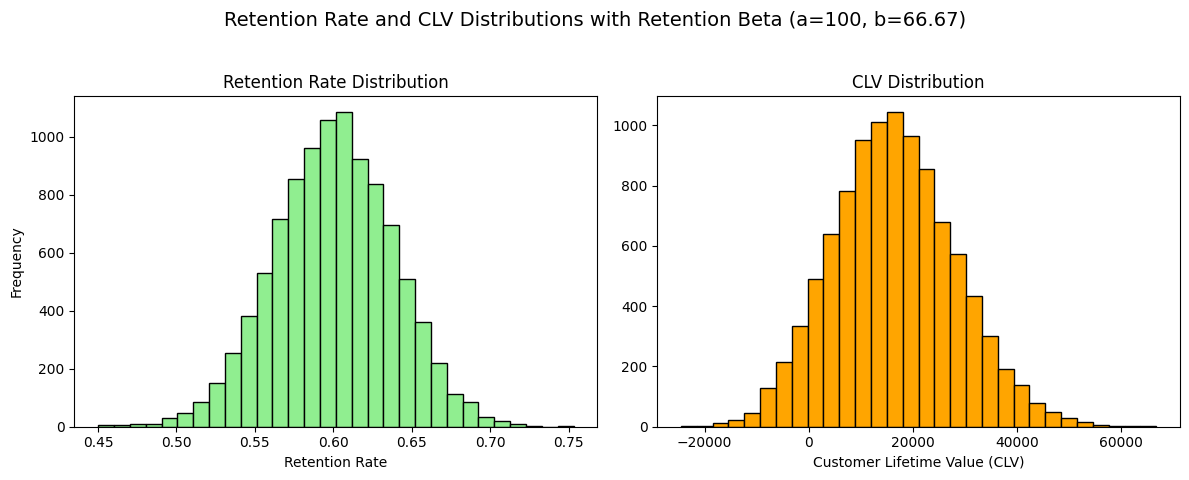

In [ ]:
r_vec_3 = beta.rvs(a_3, b_3, size=num_samples)
# Create a figure for the side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First plot: Retention Rate
ax1.hist(r_vec_3, bins=30, color='lightgreen', edgecolor='black')
ax1.set_title("Retention Rate Distribution")
ax1.set_xlabel("Retention Rate")
ax1.set_ylabel("Frequency")

# Second plot: CLV Distribution
clv_vec_3 = calculate_clv(m_vec, r_vec_3, d, ac)
ax2.hist(clv_vec_3, bins=30, color='orange', edgecolor='black')
ax2.set_title("CLV Distribution")
ax2.set_xlabel("Customer Lifetime Value (CLV)")

# Overall title with dynamic a_1 and b_1 values
fig.suptitle(f"Retention Rate and CLV Distributions with Retention Beta (a={a_3}, b={b_3:.2f})", fontsize=14)

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

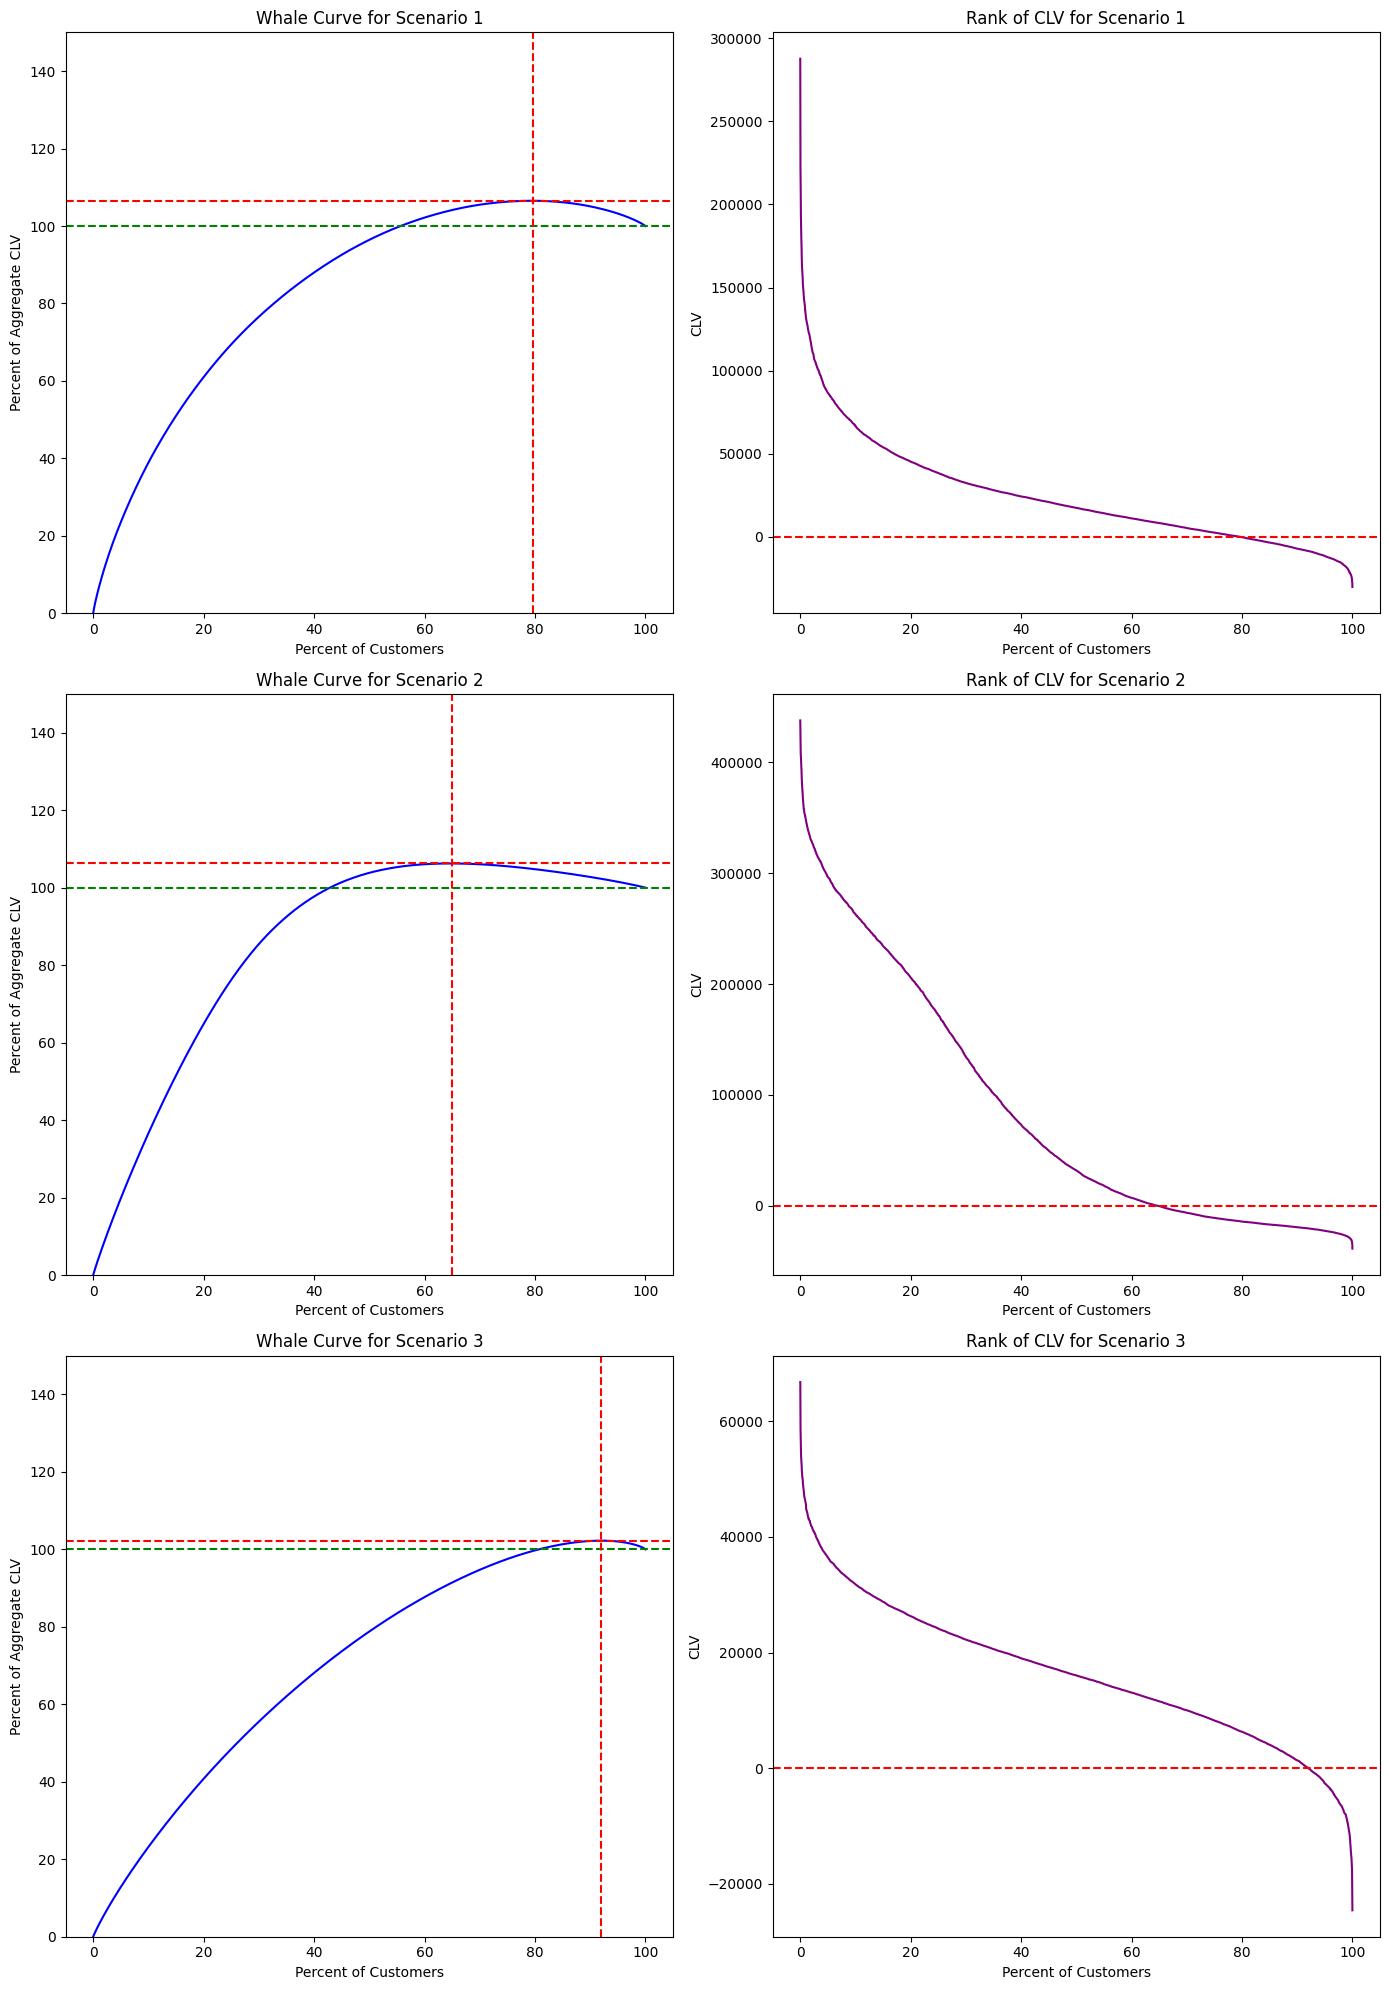

In [ ]:
# Function to create whale data for each scenario
def create_whale_data(clv_vec):
    whale_data = pd.DataFrame(sorted(clv_vec, reverse=True), columns=["clv_ordered"])
    whale_data["clv_percent"] = 100 * whale_data["clv_ordered"] / whale_data["clv_ordered"].sum()
    whale_data["clv_cumpercent"] = whale_data["clv_percent"].cumsum()
    whale_data["n_customer"] = np.arange(1, num_samples + 1)
    whale_data["percent_customers"] = 100 * whale_data["n_customer"] / num_samples
    return whale_data

# Create whale data for each scenario
whale_data_1 = create_whale_data(clv_vec_1)
whale_data_2 = create_whale_data(clv_vec_2)
whale_data_3 = create_whale_data(clv_vec_3)

# Plotting
fig, axs = plt.subplots(3, 2, figsize=(14, 20))

# Define titles for each scenario
titles = ["Scenario 1", "Scenario 2", "Scenario 3"]

# Loop over each scenario and plot the Whale Curve and Rank of CLV
for i, whale_data in enumerate([whale_data_1, whale_data_2, whale_data_3]):
    # Whale Curve Plot
    axs[i, 0].plot(whale_data["percent_customers"], whale_data["clv_cumpercent"], color='blue')
    axs[i, 0].set_title(f"Whale Curve for {titles[i]}")
    axs[i, 0].set_xlabel("Percent of Customers")
    axs[i, 0].set_ylabel("Percent of Aggregate CLV")
    axs[i, 0].set_ylim(0, 150)
    axs[i, 0].axhline(y=100, color='green', linestyle='--')

    # Identify the last customer contributing to the CLV
    last_positive_index = whale_data[whale_data["clv_ordered"] > 0].index.max()
    if last_positive_index:
        axs[i, 0].axvline(x=whale_data["percent_customers"][last_positive_index], color='red', linestyle='--')
        axs[i, 0].axhline(y=whale_data["clv_cumpercent"][last_positive_index], color='red', linestyle='--')

    # Rank of CLV Plot
    axs[i, 1].plot(whale_data["percent_customers"], whale_data["clv_ordered"], color='purple')
    axs[i, 1].set_title(f"Rank of CLV for {titles[i]}")
    axs[i, 1].set_xlabel("Percent of Customers")
    axs[i, 1].set_ylabel("CLV")
    axs[i, 1].axhline(y=0, color='red', linestyle='--')

# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [ ]:
clv_vec_1.mean()

24679.492127434998

In [ ]:
clv_vec_2.mean()

83100.68015672461

In [ ]:
clv_vec_3.mean()

16388.864821147545